# ECE334 Lab 3 — Digital building blocks

**Name:**
**Student number:**
**Date:**

This notebook is your lab report. Its sections match the manual:
<https://uoftasic.github.io/ece334-docs/labs/lab3/>

Before you start, in the container terminal:

```bash
. /foss/designs/common/.designinit
cd /foss/designs/lab3_digital
jlab
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ece334lib import measure, plot, sim

VDD = 1.8
%matplotlib inline

# Your four extracted parameters from Lab 1 P2. Replace these with YOUR
# numbers -- the values below are what the reference build extracted, and are
# here only so the cells run before you have substituted your own.
Vtn, KPn = 0.461, 177.3e-6      # V, A/V^2
Vtp, KPp = 0.992, 58.4e-6

---
## P1 / L1 — The unit inverter

$W_n = 1$, $W_p = 3$, $L = 0.5$, driving $C_L = 0.3$ pF.

Model each conducting device as an equivalent resistance:

$$R_{eq} = \frac{V_{DD}}{K_P\frac{W}{L}(V_{DD}-|V_t|)},
\qquad t_f \approx 2.2\,R_{eq,n}C_L,
\qquad t_r \approx 2.2\,R_{eq,p}C_L$$

In [2]:
# --- P1 hand analysis -------------------------------------------------------
WLn, WLp = 1 / 0.5, 3 / 0.5
CL = 0.3e-12

Req_n = VDD / (KPn * WLn * (VDD - Vtn))
Req_p = VDD / (KPp * WLp * (VDD - Vtp))

tf_hand = 2.2 * Req_n * CL
tr_hand = 2.2 * Req_p * CL

print(f"Req_n = {Req_n/1e3:6.2f} kOhm    t_fall = {tf_hand*1e12:6.0f} ps")
print(f"Req_p = {Req_p/1e3:6.2f} kOhm    t_rise = {tr_hand*1e12:6.0f} ps")

Req_n =   3.79 kOhm    t_fall =   2502 ps
Req_p =   6.36 kOhm    t_rise =   4196 ps


t_rise =   3906 ps   (hand 4196 ps)
t_fall =   2397 ps   (hand 2502 ps)
t_pHL  =   1295 ps
t_pLH  =   2143 ps


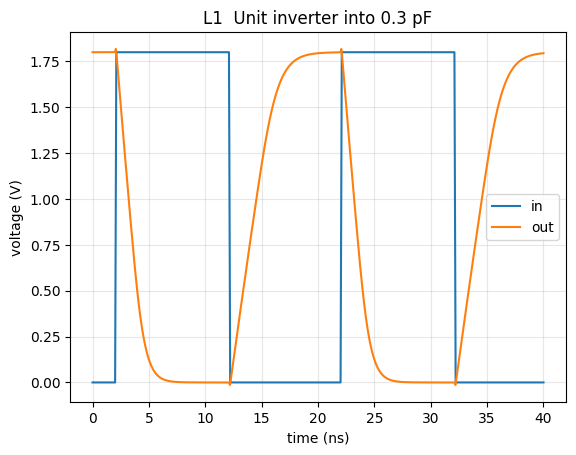

In [3]:
# --- L1 measurement ---------------------------------------------------------
inv = sim.run_deck("spice/unit_inv.spice", output="unit_inv.raw")

tr_sim, tf_sim = measure.edges_10_90(inv, "out", vdd=VDD)
tphl, tplh = measure.prop_delays(inv, "in", "out", vdd=VDD)

print(f"t_rise = {tr_sim*1e12:6.0f} ps   (hand {tr_hand*1e12:.0f} ps)")
print(f"t_fall = {tf_sim*1e12:6.0f} ps   (hand {tf_hand*1e12:.0f} ps)")
print(f"t_pHL  = {tphl*1e12:6.0f} ps")
print(f"t_pLH  = {tplh*1e12:6.0f} ps")

plot.transient(inv, ["in", "out"])
plt.title("L1  Unit inverter into 0.3 pF"); plt.show()

### Your answer

*Replace this text.* Give the measured value, what your hand analysis
predicted, the percentage difference, and one sentence explaining the gap.

The rise is slower than the fall even though the PMOS is three times wider.
Say what that tells you about the two carrier mobilities.

---
## P2 / L2 — The complex gate

$$Y = \overline{A + B\cdot C}$$

The pull-down network conducts when $A + BC$ is true: one NMOS for $A$ in
**parallel** with a **series** pair for $B$ and $C$. The pull-up is the dual.

Four input patterns matter. Fill in your P2 answer for each before you look at
the numbers.

| Case | Hold | Switch | Conducting path |
|---|---|---|---|
| Worst fall | $a=0$, $c=1$ | $b$: 0→1 | series $b$–$c$ only |
| Worst rise | $c=1$ | $b$: 1→0 | $a$ in series with $b$ alone |
| Best fall | — | $a$, $b$, $c$ together 0→1 | every pull-down path |
| Best rise | $b=c=0$ | $a$: 1→0 | both parallel PMOS |

In [4]:
# --- P2 hand analysis: what should the ratio be? ----------------------------
# The worst-case fall drives C_L through TWO series NMOS; the best case has
# every pull-down path on at once. Predict the ratio before measuring it.
worst_fall_paths = 1     # the series b-c branch, on its own
best_fall_paths  = 2     # a's branch in parallel with the b-c branch

print(f"expected t_f(worst) / t_f(best) ~ "
      f"{best_fall_paths/worst_fall_paths:.1f}x")

expected t_f(worst) / t_f(best) ~ 2.0x


In [5]:
# --- L2 measurement: all four cases in one deck -----------------------------
# yw  = worst case, ybf = best-case fall, ybr = best-case rise.
aoi = sim.run_deck("spice/aoi21_cases.spice", output="aoi21_cases.raw")

tr_w, tf_w = measure.edges_10_90(aoi, "yw",  vdd=VDD)
_,    tf_b = measure.edges_10_90(aoi, "ybf", vdd=VDD)
tr_b, _    = measure.edges_10_90(aoi, "ybr", vdd=VDD)

print(f"          {'t_f (ps)':>10} {'t_r (ps)':>10}")
print(f"worst     {tf_w*1e12:10.0f} {tr_w*1e12:10.0f}")
print(f"best      {tf_b*1e12:10.0f} {tr_b*1e12:10.0f}")
print(f"ratio     {tf_w/tf_b:10.2f} {tr_w/tr_b:10.2f}")

            t_f (ps)   t_r (ps)
worst           2078       4150
best            1092       3231
ratio           1.90       1.28


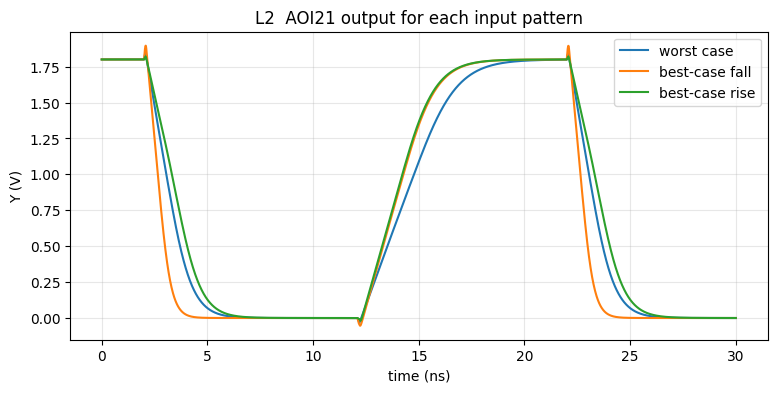

In [6]:
# --- L2: the three output waveforms together --------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
for sig, lbl in (("yw", "worst case"), ("ybf", "best-case fall"),
                 ("ybr", "best-case rise")):
    ax.plot(aoi.x * 1e9, aoi[sig], label=lbl)
ax.set_xlabel("time (ns)"); ax.set_ylabel("Y (V)")
ax.legend(); ax.grid(alpha=0.3)
plt.title("L2  AOI21 output for each input pattern"); plt.show()

### Your answer

*Replace this text.* Give the measured value, what your hand analysis
predicted, the percentage difference, and one sentence explaining the gap.

Compare the AOI21 against the unit inverter of L1. It drives five times the
load with much wider devices — did the delay go up or down, and does that match
what the $R_{eq}$ model says it should?

---
## P3 / L3 — The flip-flop

A master–slave pair. Each latch is two NOR gates in a loop that a transmission
gate closes when the input gate is open:

```
master   TG1 (CL_b) : data -> m1
         NOR_A (m1, SETQ)      -> m2
         NOR_B (m2, RESETQ)    -> m3
         TG2 (CL)   : m3 -> m1        hold while the clock is high
slave    TG3 (CL)   : m3 -> s1
         NOR_C (s1, SETQ)      -> Q_b
         NOR_D (Q_b, RESETQ)   -> Q
         TG4 (CL_b) : Q  -> s1        hold while the clock is low
```

Build it in `xschem/dff_tb.sch` and press **Netlist & Simulate**.

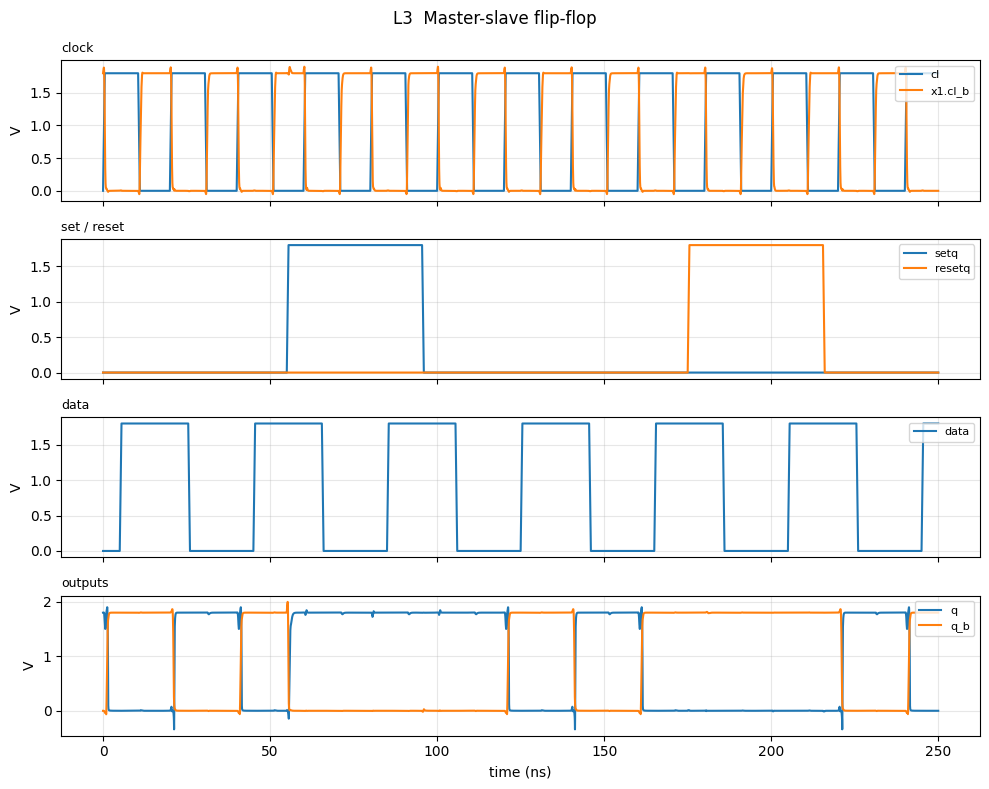

In [7]:
# --- L3: the four-panel plot ------------------------------------------------
d = sim.raw("dff_tb.raw")

panels = [(["cl", "x1.cl_b"], "clock"),
          (["setq", "resetq"], "set / reset"),
          (["data"],           "data"),
          (["q", "q_b"],       "outputs")]

fig, axes = plt.subplots(len(panels), 1, sharex=True, figsize=(10, 8))
for ax, (sigs, title) in zip(axes, panels):
    for s in sigs:
        ax.plot(d.x * 1e9, d[s], label=s)
    ax.set_ylabel("V"); ax.set_title(title, loc="left", fontsize=9)
    ax.legend(loc="upper right", fontsize=8); ax.grid(alpha=0.3)
axes[-1].set_xlabel("time (ns)")
fig.suptitle("L3  Master-slave flip-flop"); fig.tight_layout(); plt.show()

In [8]:
# --- L3: check the capture behaviour numerically ----------------------------
# Q should take the value DATA held just before each rising clock edge. Ignore
# everything before the first rising edge at 20 ns: the feedback loops start
# from an arbitrary state and take a cycle to settle.
def rising_edges(wave, sig, level=VDD/2, after=0.0):
    t, y = wave.x, wave[sig]
    below = y < level
    idx = np.flatnonzero(below[:-1] & ~below[1:])
    return t[idx][t[idx] >= after]

edges = rising_edges(d, "cl", after=20e-9)
print(f"{'clock edge':>12} {'SETQ':>5} {'RESETQ':>7} {'DATA before':>12} "
      f"{'Q after':>9}   what happened")
for te in edges[:12]:
    setq   = float(np.interp(te, d.x, d["setq"]))   > VDD/2
    resetq = float(np.interp(te, d.x, d["resetq"])) > VDD/2
    before = float(np.interp(te - 1e-9, d.x, d["data"]))
    after  = float(np.interp(te + 4e-9, d.x, d["q"]))
    # SETQ and RESETQ act through the NOR gates and override the data path
    # entirely, so an edge inside either pulse is not a capture failure --
    # it is the asynchronous input doing its job.
    if setq:
        note = "forced high by SETQ"
    elif resetq:
        note = "forced low by RESETQ"
    elif (before > VDD/2) == (after > VDD/2):
        note = "captured DATA"
    else:
        note = "MISSED -- investigate"
    print(f"{te*1e9:10.1f} ns {str(setq):>5} {str(resetq):>7} {before:11.2f} V "
          f"{after:8.2f} V   {note}")

  clock edge  SETQ  RESETQ  DATA before   Q after   what happened
      20.2 ns False   False        1.80 V     1.80 V   captured DATA
      40.2 ns False   False        0.00 V     0.00 V   captured DATA
      60.2 ns  True   False        1.80 V     1.80 V   forced high by SETQ
      80.2 ns  True   False        0.00 V     1.80 V   forced high by SETQ
     100.2 ns False   False        1.80 V     1.80 V   captured DATA
     120.2 ns False   False        0.00 V     0.00 V   captured DATA
     140.2 ns False   False        1.80 V     1.80 V   captured DATA
     160.2 ns False   False        0.00 V     0.00 V   captured DATA
     180.2 ns False    True        1.80 V     0.00 V   forced low by RESETQ
     200.2 ns False    True        0.00 V     0.00 V   forced low by RESETQ
     220.2 ns False   False        1.80 V     1.80 V   captured DATA
     240.2 ns False   False        0.00 V     0.00 V   captured DATA


### Your truth table

Fill this in from the plot. Cover, at minimum: what Q does on a rising clock
edge, what it does between edges, and what SETQ and RESETQ do irrespective of
the clock.

| CL | SETQ | RESETQ | DATA | Q | Comment |
|---|---|---|---|---|---|
| ↑ | 0 | 0 | 0 | | |
| ↑ | 0 | 0 | 1 | | |
| 0 or 1 | 0 | 0 | X | | |
| X | 1 | 0 | X | | |
| X | 0 | 1 | X | | |

Also explain why the two transmission gates in each latch are driven by
opposite clock phases. What would happen if they were driven by the same one?

### Your answer

*Replace this text.* Give the measured value, what your hand analysis
predicted, the percentage difference, and one sentence explaining the gap.

---
## Summary

| Quantity | Hand | Simulated |
|---|---|---|
| Unit inverter $t_r$ | | |
| Unit inverter $t_f$ | | |
| AOI21 worst-case $t_f$ | | |
| AOI21 best-case $t_f$ | | |
| AOI21 worst-case $t_r$ | | |
| AOI21 best-case $t_r$ | | |

Carry the unit inverter numbers into Lab 4 — the flip-flop path there is built
from these same cells.